In [1]:
import pandas as pd
import numpy as np
import re
import pickle
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import matplotlib.pyplot as plt
import seaborn as sns
import nltk
from nltk.corpus import stopwords
from gensim.models import KeyedVectors, Word2Vec
from pathlib import Path
from datetime import datetime
from collections import Counter
import json
from sklearn.model_selection import GridSearchCV

In [2]:
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10
sns.set_style('whitegrid')

try:
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')
except:
    nltk.download('stopwords')
    russian_stopwords = stopwords.words('russian')
    english_stopwords = stopwords.words('english')

In [3]:
train_bodies = pd.read_csv('./data/train_bodies.csv')
test_bodies = pd.read_csv('./data/test_bodies.csv')

train_stances = pd.read_csv('./data/train_stances.csv')
test_stances = pd.read_csv('./data/test_stances_unlebeledb.csv') 

In [4]:
train_stances.head(3)

,Unnamed: 0,Body ID,Headline,Stance,Headline1,Headline2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...


# Проведем предобработку данных

## Объединим данные

In [5]:
train_data = train_stances.merge(train_bodies, on='Body ID', how='left')
test_data = test_stances.merge(test_bodies, on='Body ID', how='left')

In [6]:
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...


## Проведем предобработку русского языка

In [7]:
def preprocess_text(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^а-яё\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in russian_stopwords and len(word) > 2]
    
    return ' '.join(words)

def preprocess_text_en(text):
    if not isinstance(text, str) or len(text) == 0:
        return ""
    
    text = text.lower()
    text = re.sub(r'http\S+|www\S+|https\S+', '', text)
    text = re.sub(r'\S+@\S+', '', text)
    text = re.sub(r'<.*?>', '', text)
    text = re.sub(r'[^a-z\s]', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip()
    
    words = text.split()
    words = [word for word in words if word not in english_stopwords and len(word) > 2]
    
    return ' '.join(words)


## Обработка заголовков и текстов

In [8]:
eng_data = pd.read_csv("./data/eng_data")

eng_data = eng_data.rename(columns={'title': 'Headline', 'text': 'articleBody'})

eng_data.sample(3)

,Headline,articleBody,label
12844,Spanish court grants U.S. extradition for Russ...,MADRID (Reuters) - Spain s High Court said on ...,1
8752,PROTESTER HITS COP ON HEAD WITH BALLOON…WATCH ...,***TURN DOWN THE VOLUME***These are the pathet...,0
524,Progressives Outraged Over Beyonce “So White” ...,American liberal activists still struggling wi...,0


In [9]:
train_data['headline_clean'] = train_data['Headline'].apply(preprocess_text)
train_data['body_clean'] = train_data['articleBody'].apply(preprocess_text)

test_data['headline_clean'] = test_data['Headline'].apply(preprocess_text)
test_data['body_clean'] = test_data['articleBody'].apply(preprocess_text)

eng_data['headline_clean'] = eng_data['Headline'].apply(preprocess_text_en)
eng_data['body_clean'] = eng_data['articleBody'].apply(preprocess_text_en)

In [10]:
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean
21824,Two Trump Tweets Debunk Russian Connection Con...,21st Century Wire says Partisan liberal hypocr...,0,two trump tweets debunk russian connection con...,century wire says partisan liberal hypocrisy s...
14507,Turkey's tourism earnings to reach $30 billion...,LONDON (Reuters) - Turkey s crucial tourism se...,1,turkey tourism earnings reach billion minister...,london reuters turkey crucial tourism sector s...
6718,Ben & Jerry’s Ice Cream Founders Get Arrested...,"The co-founders of Ben & Jerry s Ice Cream, Be...",0,ben jerry ice cream founders get arrested capitol,founders ben jerry ice cream ben cohen jerry g...


## Создадим комбинированные признаки (заголовок + начало текста)

In [11]:
def combine_features(row):
    headline = row['headline_clean']
    body_words = row['body_clean'].split()
    body = ' '.join(body_words)
    return f"{headline} {body}"

In [12]:
train_data['combined_text'] = train_data.apply(combine_features, axis=1)
test_data['combined_text'] = test_data.apply(combine_features, axis=1)
eng_data['combined_text'] = eng_data.apply(combine_features, axis=1)

In [13]:
train_data = train_data[train_data['combined_text'].str.len() > 10].reset_index(drop=True)
test_data = test_data[test_data['combined_text'].str.len() > 10].reset_index(drop=True)
eng_data = eng_data[eng_data['combined_text'].str.len() > 10].reset_index(drop=True)

In [ ]:
train_data['text_length'] = train_data['combined_text'].str.split().str.len()
print(f"\nСтатистика длины комбинированных текстов (в словах):")
print(train_data['text_length'].describe())

train_data_tf = train_data


Статистика длины комбинированных текстов (в словах):
count    4408.000000
mean      136.134528
std        69.050534
min         9.000000
25%       101.000000
50%       126.000000
75%       153.000000
max      1084.000000
Name: text_length, dtype: float64


In [15]:
train_data.iloc[0]

Unnamed: 0_x                                                      0
Body ID                                                           1
Headline          ['российский', 'бюджет', 'марте', 'недополучил...
Stance                                                        agree
Headline1         российский бюджет в марте недополучил более 30...
Headline2         российский бюджет март недополучать миллиард р...
Unnamed: 0_y                                                      0
articleBody       Разница между ожидаемыми по итогам марта нефте...
articleBody1      разница ожидаемыми итогам марта нефтегазовыми ...
articleBody2      разница ожидать итог март нефтегазовый доход ф...
headline_clean    российский бюджет марте недополучил миллиардов...
body_clean        разница ожидаемыми итогам марта нефтегазовыми ...
combined_text     российский бюджет марте недополучил миллиардов...
text_length                                                      73
Name: 0, dtype: object

## Подготовим целевую переменную
---
где:
* Реальная новость - 1
* Фейк - 0

In [16]:
label_mapping = {'agree': 1, 'disagree': 0}

train_data['label'] = train_data['Stance'].map(label_mapping)
train_data.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


In [17]:
train_data_tf['label'] = train_data_tf['Stance'].map(label_mapping)
train_data_tf.head(3)

,Unnamed: 0_x,Body ID,Headline,Stance,Headline1,Headline2,Unnamed: 0_y,articleBody,articleBody1,articleBody2,headline_clean,body_clean,combined_text,text_length,label
0,0,1,"['российский', 'бюджет', 'марте', 'недополучил...",agree,российский бюджет в марте недополучил более 30...,российский бюджет март недополучать миллиард р...,0,Разница между ожидаемыми по итогам марта нефте...,разница ожидаемыми итогам марта нефтегазовыми ...,разница ожидать итог март нефтегазовый доход ф...,российский бюджет марте недополучил миллиардов...,разница ожидаемыми итогам марта нефтегазовыми ...,российский бюджет марте недополучил миллиардов...,73,1
1,1,2,"['банк', 'россии', 'решил', 'снизить', 'ключев...",agree,банк россии решил снизить ключевую ставку с 20...,банк россия решать снижать ключевой ставка,1,Совет директоров Банка России решил снизить кл...,совет директоров банка россии решил снизить кл...,совет директор банк россия решать снижать ключ...,банк россии решил снизить ключевую ставку,совет директоров банка россии решил снизить кл...,банк россии решил снизить ключевую ставку сове...,57,1
2,2,3,"['мыс', 'идокопас', 'нато', 'назвали', 'первую...",disagree,мыс идокопас в нато назвали первую цель для н...,мыс идокопас нато называть первый цель начало ...,2,В НАТО составили наступательный план действий ...,нато составили наступательный план действий за...,нато составлять наступательный план действие з...,мыс идокопас нато назвали первую цель начала п...,нато составили наступательный план действий за...,мыс идокопас нато назвали первую цель начала п...,100,0


### Удалим все лишнее

In [18]:
train_data.drop(columns=["Unnamed: 0_x", "Body ID", "Headline", "Headline1", "Headline2", "Unnamed: 0_y", "articleBody",
                         "articleBody1", "articleBody2", "Stance"], inplace=True)

In [19]:
train_data.sample(3)

,headline_clean,body_clean,combined_text,text_length,label
4138,автобусах возили президенту деды заняли места ...,анатолий вассерман поделился своими впечатлени...,автобусах возили президенту деды заняли места ...,156,0
1008,пожимает руку невидимке американка назвала бай...,танцовщица одного клубов лас вегаса мелани гри...,пожимает руку невидимке американка назвала бай...,111,0
2376,киссинджер хрущёв работал цру,американский дипломат генри киссинджер интервь...,киссинджер хрущёв работал цру американский дип...,142,0


# Word2Vec

## Загрузим эмбеддинги

In [20]:
sentences = [text.split() for text in train_data['body_clean']] + [text.split() for text in train_data['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

## Функция для получения усреднённого вектора

In [21]:
def doc_vector(tokens, kv_model):
    vecs = [kv_model[w] for w in tokens if w in kv_model]
    if not vecs:
        return np.zeros(kv_model.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

## Соберем признаки: headline_vec, body_vec, косинусная близость

In [22]:
def cosine(u, v):
    nu, nv = np.linalg.norm(u), np.linalg.norm(v)
    if nu == 0 or nv == 0:
        return 0.0
    return float(np.dot(u, v) / (nu * nv))

def jaccard(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A and not B:
        return 0.0
    return len(A & B) / max(1, len(A | B))

def overlap_ratio(a_tokens, b_tokens):
    A, B = set(a_tokens), set(b_tokens)
    if not A:
        return 0.0
    return len(A & B) / len(A)

def elementwise_stats(h_vec, b_vec):
    diff = np.abs(h_vec - b_vec)              
    prod = h_vec * b_vec                      
    l2 = np.linalg.norm(h_vec - b_vec)        
    return diff, prod, l2

def build_features(df, kv, max_len=150):
    H, B, COS, JAC, OVR, L2, DIFF, PROD = [], [], [], [], [], [], [], []
    for i, row in df.iterrows():
        htoks = row['headline_clean'].split()[:max_len]
        btoks = row['body_clean'].split()[:max_len]

        h_vec = doc_vector(htoks, kv)
        b_vec = doc_vector(btoks, kv)

        H.append(h_vec); B.append(b_vec)

        COS.append(cosine(h_vec, b_vec))
        JAC.append(jaccard(htoks, btoks))
        OVR.append(overlap_ratio(htoks, btoks))

        diff, prod, l2 = elementwise_stats(h_vec, b_vec)
        DIFF.append(diff); PROD.append(prod); L2.append(l2)

    H = np.vstack(H); B = np.vstack(B)
    COS = np.array(COS).reshape(-1, 1)
    JAC = np.array(JAC).reshape(-1, 1)
    OVR = np.array(OVR).reshape(-1, 1)
    L2  = np.array(L2).reshape(-1, 1)
    DIFF = np.vstack(DIFF)     # размер N, d
    PROD = np.vstack(PROD)     # размер N, d

    X = np.hstack([H, B, DIFF, PROD, COS, JAC, OVR, L2])
    return X

## Подготовка X и y

In [23]:
X = build_features(train_data, kv)
y = train_data['label'].values

## Разделим

In [24]:
X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Обучим модель логистической регрессии и рандомного леса. Прогоним по метрикам

In [25]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

Path("models").mkdir(parents=True, exist_ok=True)

In [26]:
param_grids = {
    'LogisticRegression': {
        'C': [0.1, 0.5, 1, 2, 5],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced']
    }
}

In [27]:
results = {}
metrics_dict = {}

for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name], cv=3,
                        scoring='f1_weighted', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred,
                                target_names=['Фейк (disagree)', 'Реальная (agree)'],
                                digits=4))

    # Сохранение модели
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model.pkl", "wb") as f:
        pickle.dump(best_model, f)

    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }

    metrics_dict[model_name] = {
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

Path("results/metrics").mkdir(parents=True, exist_ok=True)
with open("results/metrics/metrics_w2v.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

# Эмбеддинги
kv.save("models/w2v_vectors.kv")


--- LogisticRegression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9498
Val Accuracy:   0.9184
Val F1-Score:   0.9184

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9189    0.9189    0.9189       444
Реальная (agree)     0.9178    0.9178    0.9178       438

        accuracy                         0.9184       882
       macro avg     0.9184    0.9184    0.9184       882
    weighted avg     0.9184    0.9184    0.9184       882


--- RandomForest: подбор гиперпараметров ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}
Train Accuracy: 1.0000
Val Accuracy:   0.9195
Val F1-Score:   0.9195

Classification Report:
                  precision    recall  f1-sco

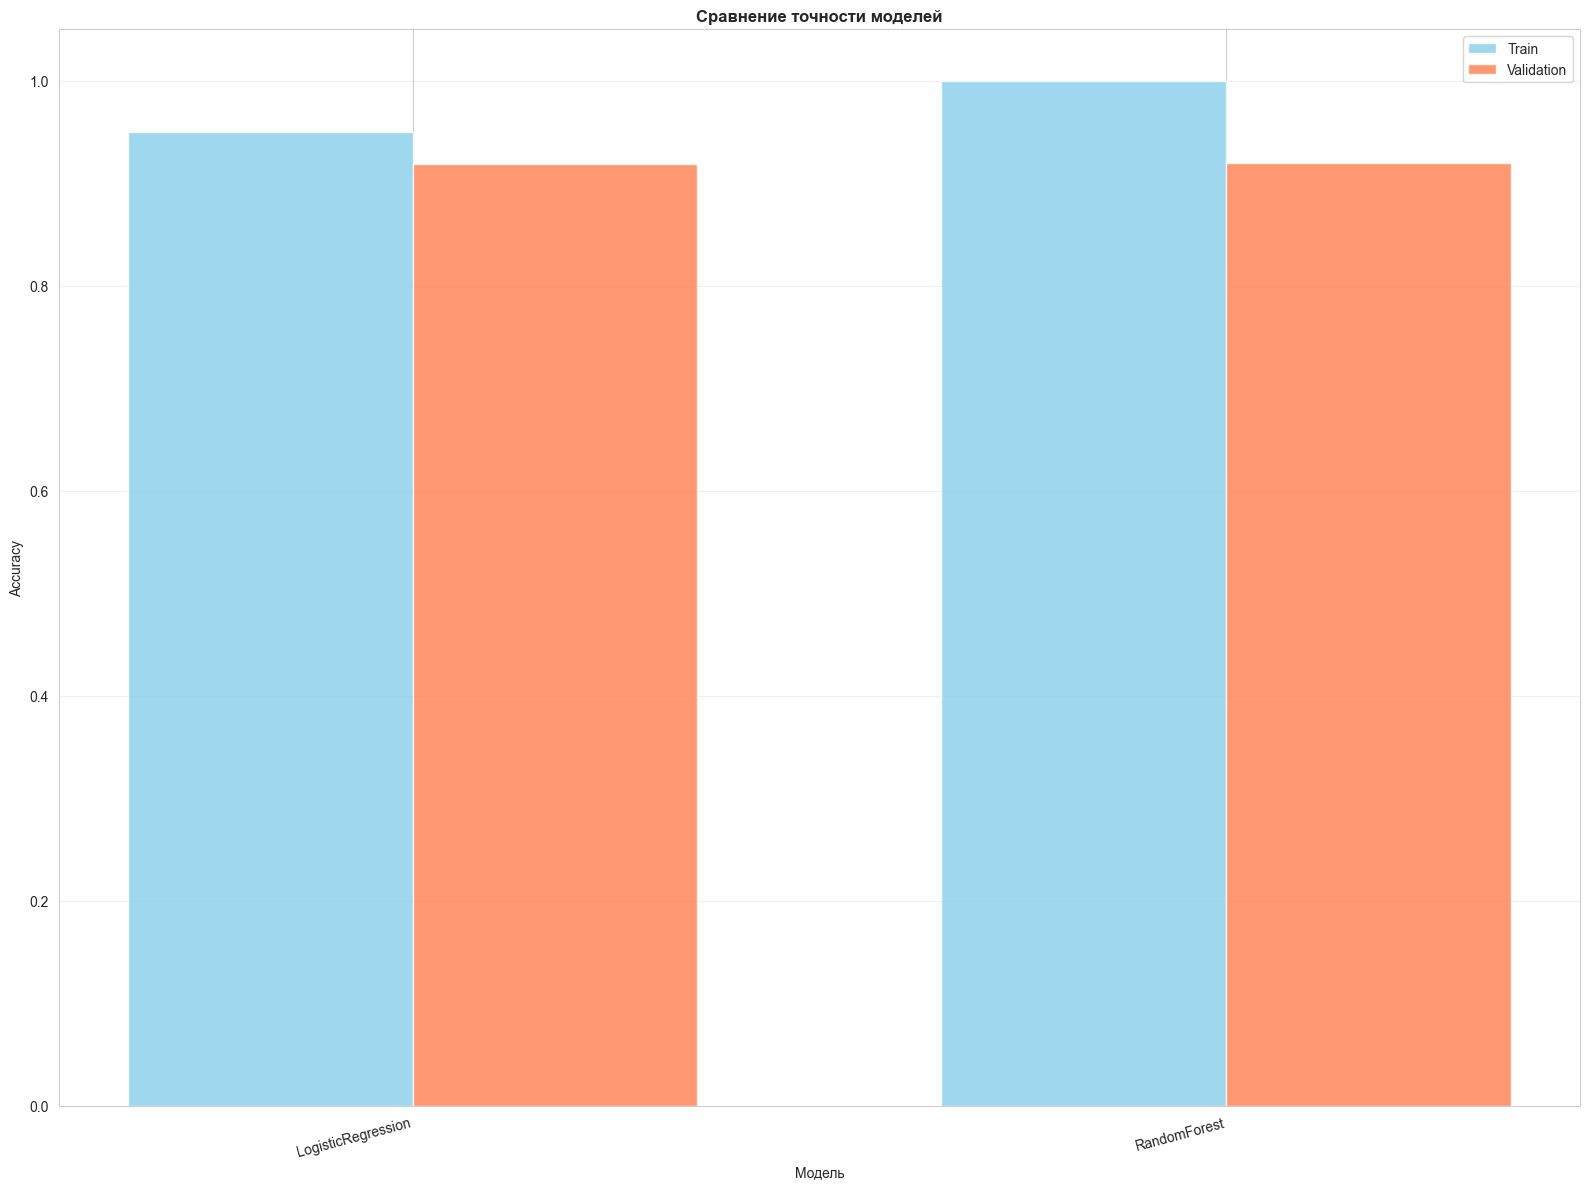

In [28]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
val_accs = [results[name]['val_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax.bar(x + width/2, val_accs, width, label='Validation', alpha=0.8, color='coral')
ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение точности моделей', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/models_scores_w2v.png', dpi=300)

# TF-IDF

## Разделим данные

In [29]:
X = train_data_tf['combined_text']
y = train_data_tf['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [30]:
print(f"\nРаспределение классов в train:")
print(y_train.value_counts())
print(f"\nРаспределение классов в validation:")
print(y_val.value_counts())


Распределение классов в train:
label
0    1777
1    1749
Name: count, dtype: int64

Распределение классов в validation:
label
0    444
1    438
Name: count, dtype: int64


## Векторизация

In [31]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),  
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%")

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.97%


## Обучим 3 модели и в последствии выберем лучшую
---
* Logistic Regression
* Naive Bayes
* Random Forest

In [32]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'Naive Bayes': MultinomialNB(),
    'Random Forest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

In [33]:
param_grids = {
    'Logistic Regression': {
        'C': [0.1, 0.5, 1, 2, 5],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    },
    'Naive Bayes': {
        'alpha': [0.01, 0.1, 0.5, 1.0]
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced']
    }
}

In [34]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name],
                        cv=3, scoring='f1_weighted',
                        n_jobs=-1, verbose=1)
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_val, y_val_pred,
        target_names=['Фейк (disagree)', 'Реальная (agree)'],
        digits=4
    ))

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

    with open(f"models/{model_name}_model_tf.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_tuned.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': 'balanced', 'max_iter': 500, 'solver': 'lbfgs'}
Train Accuracy: 0.9983
Val Accuracy:   0.9603
Val F1-Score:   0.9603

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9455    0.9775    0.9612       444
Реальная (agree)     0.9764    0.9429    0.9593       438

        accuracy                         0.9603       882
       macro avg     0.9609    0.9602    0.9603       882
    weighted avg     0.9608    0.9603    0.9603       882


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 1.0}
Train Accuracy: 0.9606
Val Accuracy:   0.9365
Val F1-Score:   0.9364

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9145    0.9640    0.9386       444
Ре

## Проверим на метриках

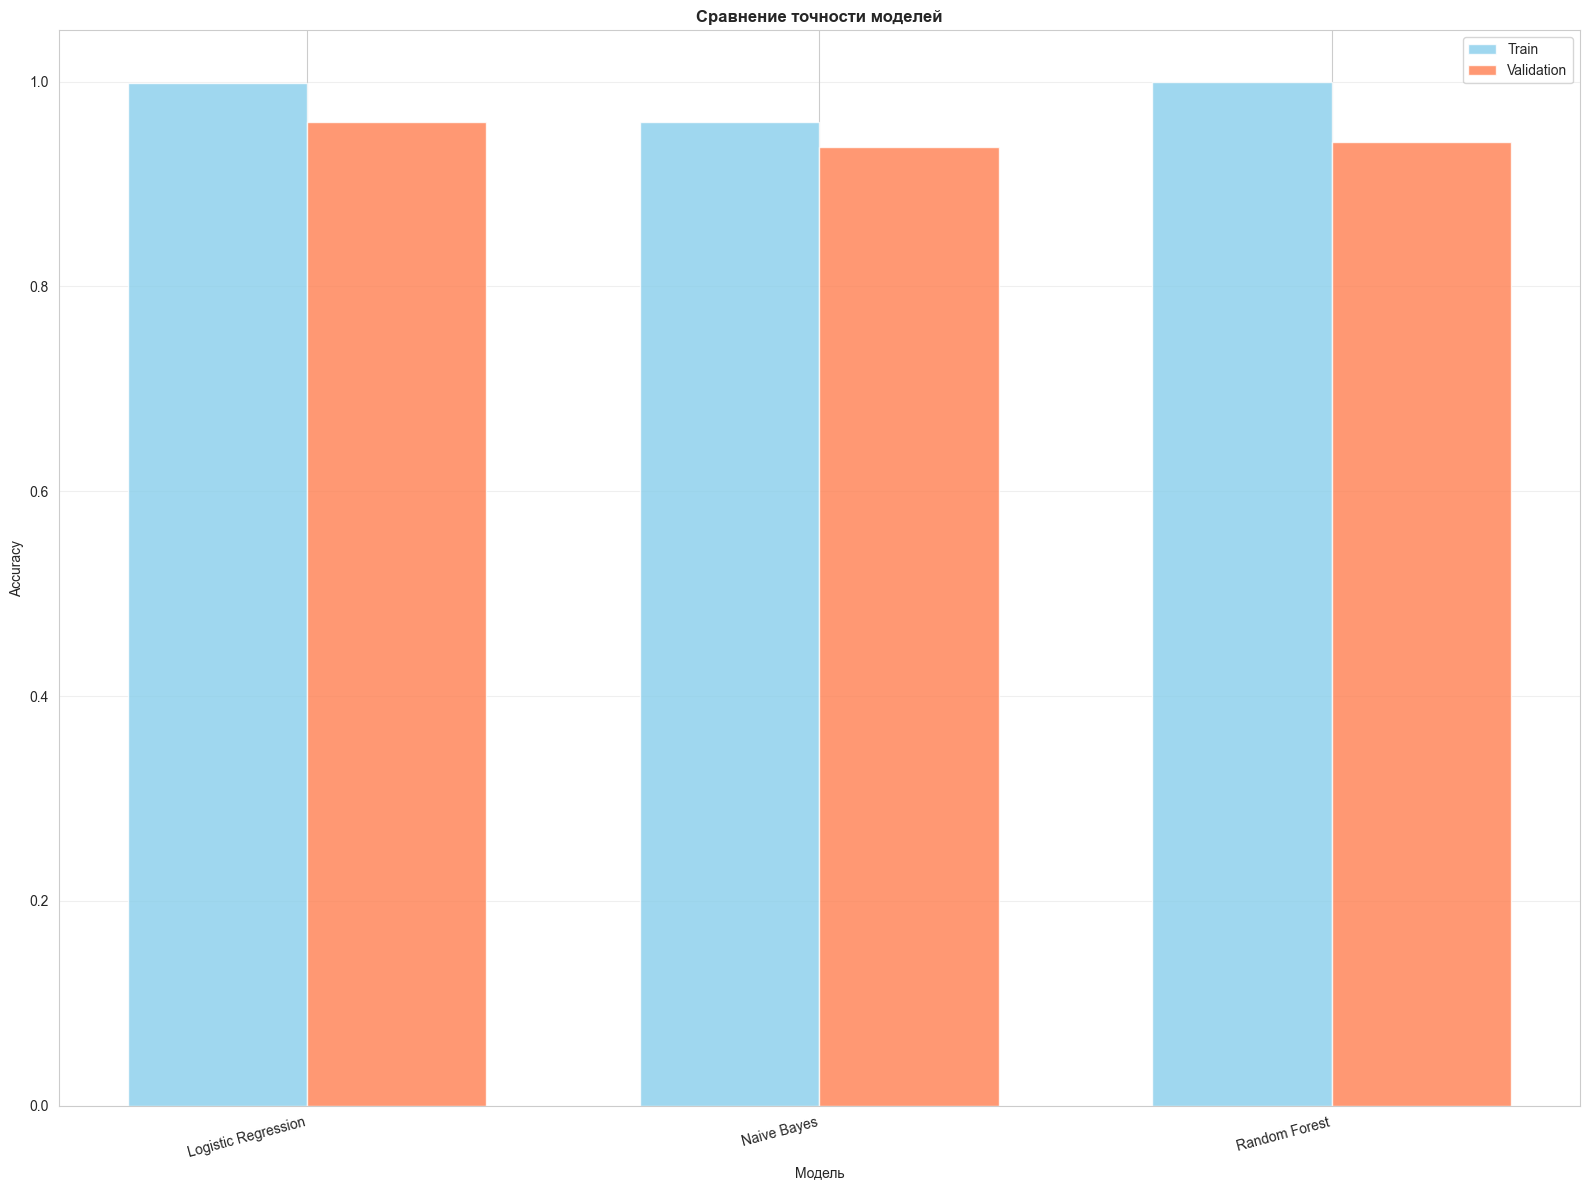

In [35]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

model_names = list(results.keys())
train_accs = [results[name]['train_acc'] for name in model_names]
val_accs = [results[name]['val_acc'] for name in model_names]

x = np.arange(len(model_names))
width = 0.35

ax.bar(x - width/2, train_accs, width, label='Train', alpha=0.8, color='skyblue')
ax.bar(x + width/2, val_accs, width, label='Validation', alpha=0.8, color='coral')
ax.set_xlabel('Модель')
ax.set_ylabel('Accuracy')
ax.set_title('Сравнение точности моделей', fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=15, ha='right')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/models_scores.png', dpi=300)


In [36]:
train_data['text_length'] = train_data['combined_text'].str.split().str.len()

train_data_tf = train_data

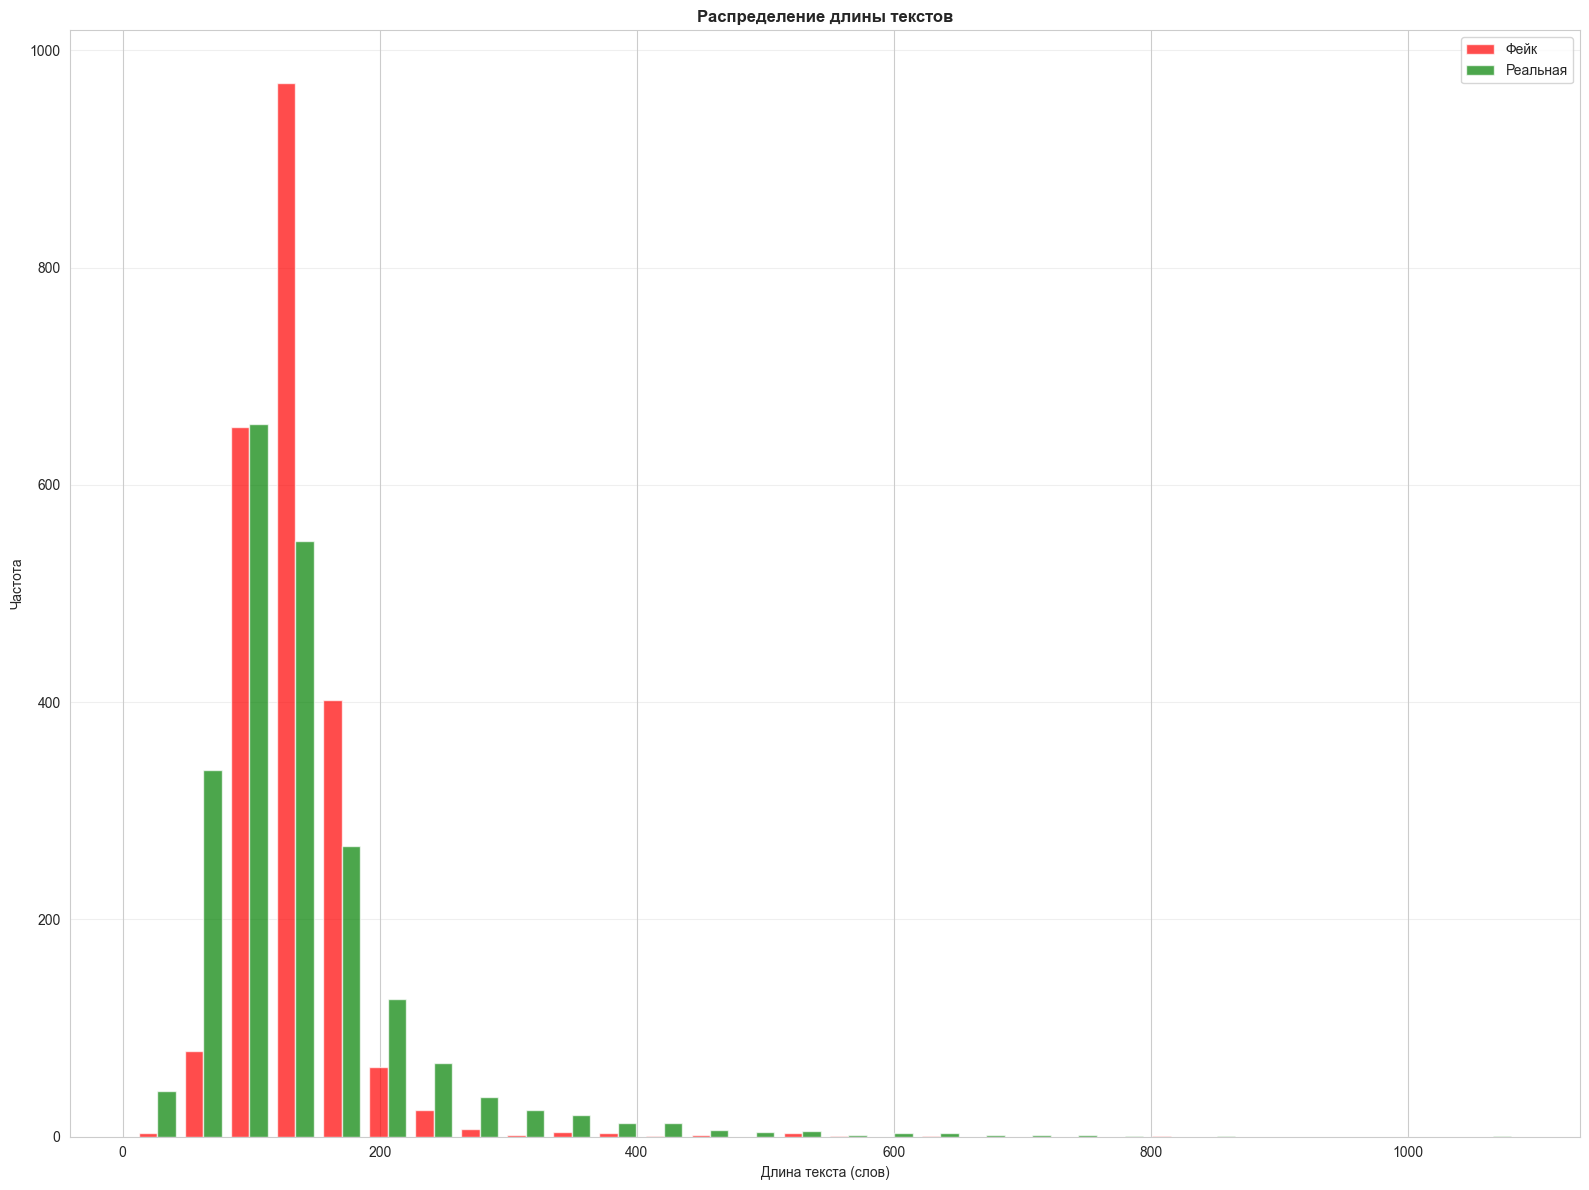

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(16, 12))

ax.hist(
    [train_data_tf[train_data_tf['label']==0]['text_length'],
     train_data_tf[train_data_tf['label']==1]['text_length']],
    bins=30, label=['Фейк', 'Реальная'], alpha=0.7, color=['red', 'green']
)
ax.set_xlabel('Длина текста (слов)')
ax.set_ylabel('Частота')
ax.set_title('Распределение длины текстов', fontweight='bold')
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('./assets/text_lenght.png', dpi=300)

## Сохраним модели

In [38]:
# for name, info in results.items():
#     model = info['models']
#     filename = f'./models/{name}_model_tf.pkl'
#     with open(filename, 'wb') as f:
#         pickle.dump(model, f)
#     print(f"Модель {name} сохранена в {filename}")

# Также сохраняем векторизатор и лейблы (общие для всех моделей)
with open('./models/tfidf_vectorizer_tf.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('./models/label_mapping_tf.pkl', 'wb') as f:
    pickle.dump(label_mapping, f)


In [39]:
# from pathlib import Path

# # Формируем словарь метрик
# metrics = {
#     model_name: {
#         "val_acc": results[model_name]["val_acc"]
#     }
#     for model_name in results
# }

# # Создаём каталог, если его нет
# Path("results/metrics").mkdir(parents=True, exist_ok=True)

# # Сохраняем метрики в JSON
# with open("results/metrics/metrics.json", "w", encoding="utf-8") as f:
#     json.dump(metrics, f, ensure_ascii=False, indent=2)

# print("Метрики сохранены в results/metrics/metrics.json")


# TF-IDF на английском датасете (Обработка датасета выше)

In [40]:
sentences = [text.split() for text in eng_data['body_clean']] + [text.split() for text in eng_data['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

In [41]:
eng_data['text_length'] = eng_data['combined_text'].str.split().str.len()
eng_data.sample(3)

,Headline,articleBody,label,headline_clean,body_clean,combined_text,text_length
20242,Dave Chappelle: ‘I F***ed Up’ When Asking To ...,"Comedian Dave Chappelle, known for his razor-s...",0,dave chappelle asking give trump chance details,comedian dave chappelle known razor sharp hila...,dave chappelle asking give trump chance detail...,194
19773,Kellyanne Conway Just Can’t Stop Talking Abou...,With nothing else important going on in the wo...,0,kellyanne conway stop talking anderson cooper ...,nothing else important going world white house...,kellyanne conway stop talking anderson cooper ...,214
16347,AL Cop Goes Ballistic On Fellow Officer Over ...,"A Birmingham, Alabama police officer was arres...",0,cop goes ballistic fellow officer records disp...,birmingham alabama police officer arrested wee...,cop goes ballistic fellow officer records disp...,179


In [42]:
X = eng_data['combined_text']
y = eng_data['label']

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

In [43]:
vectorizer = TfidfVectorizer(
    max_features=8000,
    ngram_range=(1, 2),  
    min_df=3,
    max_df=0.85,
    sublinear_tf=True
)

X_train_vec = vectorizer.fit_transform(X_train)
X_val_vec = vectorizer.transform(X_val)

print(f"✓ Размерность векторов: {X_train_vec.shape[1]} признаков")
print(f"✓ Разреженность: {(1 - X_train_vec.nnz / (X_train_vec.shape[0] * X_train_vec.shape[1])) * 100:.2f}%")

✓ Размерность векторов: 8000 признаков
✓ Разреженность: 98.05%


In [44]:
results = {}
metrics_dict = {}

# Цикл по моделям с подбором гиперпараметров
for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name],
                        cv=3, scoring='f1_weighted',
                        n_jobs=-1, verbose=1)
    grid.fit(X_train_vec, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train_vec)
    y_val_pred = best_model.predict(X_val_vec)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(
        y_val, y_val_pred,
        target_names=['Фейк (disagree)', 'Реальная (agree)'],
        digits=4
    ))

    # Сохраняем результаты и модели
    model_name = name.lower().replace(" ", "_")
    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }
    metrics_dict[model_name] = {
        "val_acc": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

    with open(f"models/{model_name}_model_tf_eng.pkl", "wb") as f:
        pickle.dump(best_model, f)

# Сохраняем метрики в JSON
with open("results/metrics/metrics_tfidf_eng.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

print("\nПодбор гиперпараметров завершён успешно!")


--- Logistic Regression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'liblinear'}
Train Accuracy: 0.9992
Val Accuracy:   0.9968
Val F1-Score:   0.9968

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9994    0.9955    0.9974      3328
Реальная (agree)     0.9927    0.9990    0.9958      2029

        accuracy                         0.9968      5357
       macro avg     0.9960    0.9973    0.9966      5357
    weighted avg     0.9968    0.9968    0.9968      5357


--- Naive Bayes: подбор гиперпараметров ---
Fitting 3 folds for each of 4 candidates, totalling 12 fits
Лучшие параметры: {'alpha': 0.01}
Train Accuracy: 0.9861
Val Accuracy:   0.9854
Val F1-Score:   0.9855

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9921    0.9844    0.9882      3328
Реа

In [45]:
with open('./models/tfidf_vectorizer_tf_eng.pkl', 'wb') as f:
    pickle.dump(vectorizer, f)

with open('./models/label_mapping_tf_eng.pkl', 'wb') as f:
    pickle.dump(label_mapping, f)

# Word2Vec на английском датасете

In [46]:
sentences = [text.split() for text in eng_data['body_clean']] + [text.split() for text in eng_data['headline_clean']]
w2v = Word2Vec(sentences, vector_size=300, window=3, min_count=3, sg=1, workers=4, epochs=10)
kv = w2v.wv

In [47]:
def docvector(tokens, kvmodel):
    vecs = [kvmodel[w] for w in tokens if w in kvmodel]
    if not vecs: return np.zeros(kvmodel.vector_size, dtype=np.float32)
    return np.vstack(vecs).mean(axis=0)

def buildfeatures(df, kv, maxlen=150):
    H, B, COS, JAC, OVR, L2, DIFF, PROD = [], [], [], [], [], [], [], []
    for i, row in df.iterrows():
        htoks = row['headline_clean'].split()[:maxlen]
        btoks = row['body_clean'].split()[:maxlen]
        hvec = docvector(htoks, kv)
        bvec = docvector(btoks, kv)
        H.append(hvec)
        B.append(bvec)
        COS.append(float(np.dot(hvec, bvec) / (np.linalg.norm(hvec) * np.linalg.norm(bvec) + 1e-9)))
        # ... (или интегрируй твои фичи по аналогии с имеющимся buildfeatures)
    X = np.hstack([np.vstack(H), np.vstack(B), np.array(COS).reshape(-1, 1)])
    return X


In [52]:
X = buildfeatures(eng_data, kv)
y = eng_data['label'].values
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [53]:
models = {
    'LogisticRegression': LogisticRegression(random_state=42),
    'RandomForest': RandomForestClassifier(random_state=42, n_jobs=-1)
}

Path("models").mkdir(parents=True, exist_ok=True)

In [54]:
param_grids = {
    'LogisticRegression': {
        'C': [0.1, 0.5, 1, 2, 5],
        'solver': ['liblinear', 'lbfgs'],
        'max_iter': [500, 1000, 2000],
        'class_weight': ['balanced', None]
    },
    'RandomForest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 20, 30, None],
        'min_samples_split': [2, 5, 10],
        'class_weight': ['balanced']
    }
}

In [56]:
results = {}
metrics_dict = {}

for name, model in models.items():
    print(f"\n--- {name}: подбор гиперпараметров ---")

    grid = GridSearchCV(model, param_grids[name], cv=3,
                        scoring='f1_weighted', n_jobs=-1, verbose=1)
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_

    # Предсказания
    y_train_pred = best_model.predict(X_train)
    y_val_pred = best_model.predict(X_val)

    # Метрики
    train_acc = accuracy_score(y_train, y_train_pred)
    val_acc = accuracy_score(y_val, y_val_pred)
    val_f1 = f1_score(y_val, y_val_pred, average='weighted')

    print(f"Лучшие параметры: {grid.best_params_}")
    print(f"Train Accuracy: {train_acc:.4f}")
    print(f"Val Accuracy:   {val_acc:.4f}")
    print(f"Val F1-Score:   {val_f1:.4f}")
    print("\nClassification Report:")
    print(classification_report(y_val, y_val_pred,
                                target_names=['Фейк (disagree)', 'Реальная (agree)'],
                                digits=4))

    # Сохранение модели
    model_name = name.lower().replace(" ", "_")
    with open(f"models/{model_name}_model_w2v_eng.pkl", "wb") as f:
        pickle.dump(best_model, f)

    results[name] = {
        'best_params': grid.best_params_,
        'train_acc': train_acc,
        'val_acc': val_acc,
        'val_f1': val_f1
    }

    metrics_dict[model_name] = {
        "val_accuracy": val_acc,
        "val_f1": val_f1,
        "best_params": grid.best_params_
    }

Path("results/metrics").mkdir(parents=True, exist_ok=True)
with open("results/metrics/metrics_w2v_eng.json", "w", encoding="utf-8") as f:
    json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

# Эмбеддинги
kv.save("models/w2v_vectors_eng.kv")


--- LogisticRegression: подбор гиперпараметров ---
Fitting 3 folds for each of 60 candidates, totalling 180 fits
Лучшие параметры: {'C': 5, 'class_weight': None, 'max_iter': 500, 'solver': 'liblinear'}
Train Accuracy: 0.9967
Val Accuracy:   0.9914
Val F1-Score:   0.9914

Classification Report:
                  precision    recall  f1-score   support

 Фейк (disagree)     0.9916    0.9946    0.9931      3328
Реальная (agree)     0.9911    0.9862    0.9886      2029

        accuracy                         0.9914      5357
       macro avg     0.9913    0.9904    0.9909      5357
    weighted avg     0.9914    0.9914    0.9914      5357


--- RandomForest: подбор гиперпараметров ---
Fitting 3 folds for each of 36 candidates, totalling 108 fits
Лучшие параметры: {'class_weight': 'balanced', 'max_depth': 20, 'min_samples_split': 2, 'n_estimators': 300}
Train Accuracy: 1.0000
Val Accuracy:   0.9823
Val F1-Score:   0.9823

Classification Report:
                  precision    recall  f1-s

In [ ]:
# lr = LogisticRegression(random_state=42).fit(Xtrain, ytrain)
# rf = RandomForestClassifier(random_state=42, n_jobs=-1).fit(Xtrain, ytrain)

# print("--- Word2Vec + Logistic Regression ---")
# print("Train accuracy:", lr.score(Xtrain, ytrain))
# print("Validation accuracy:", lr.score(Xval, yval))
# print(classification_report(yval, lr.predict(Xval)))

# print("--- Word2Vec + RandomForest ---")
# print("Train accuracy:", rf.score(Xtrain, ytrain))
# print("Validation accuracy:", rf.score(Xval, yval))
# print(classification_report(yval, rf.predict(Xval)))

--- Word2Vec + Logistic Regression ---
Train accuracy: 0.9922050037341299
Validation accuracy: 0.9893597162591002
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3328
           1       0.99      0.99      0.99      2029

    accuracy                           0.99      5357
   macro avg       0.99      0.99      0.99      5357
weighted avg       0.99      0.99      0.99      5357

--- Word2Vec + RandomForest ---
Train accuracy: 1.0
Validation accuracy: 0.9822661937651671
              precision    recall  f1-score   support

           0       0.99      0.99      0.99      3328
           1       0.98      0.98      0.98      2029

    accuracy                           0.98      5357
   macro avg       0.98      0.98      0.98      5357
weighted avg       0.98      0.98      0.98      5357



In [ ]:
# for name, model in models.items():
#     model_name = name.lower().replace(" ", "_")
#     Path("models").mkdir(exist_ok=True)
#     with open(f"models/{model_name}_word2vec_eng.pkl", "wb") as f:
#         pickle.dump(best_model, f)

#     results[name] = {
#         'best_params': grid.best_params_,
#         'train_acc': train_acc,
#         'val_acc': val_acc,
#         'val_f1': val_f1
#     }
#     metrics_dict[model_name] = {
#         "val_accuracy": val_acc,
#         "val_f1": val_f1,
#         "best_params": grid.best_params_
#     }
#     Path("results/metrics").mkdir(parents=True, exist_ok=True)
#     with open("results/metrics/metrics_w2v_engdata.json", "w", encoding="utf-8") as f:
#         json.dump(metrics_dict, f, ensure_ascii=False, indent=4)

#     # --- Сохраняем Word2Vec эмбеддинги ---
#     kv.save("models/w2v_vectors_engdata.kv")